In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F

from matplotlib import pyplot as plt
from tqdm import tqdm as tqdm
import math
from matplotlib.colors import ListedColormap
import seaborn as sns

%matplotlib inline
#device = torch.device("mps" if torch.backends.mps.is_built() else "cpu")
device = "cpu"
print(device)

cpu


## create dataset

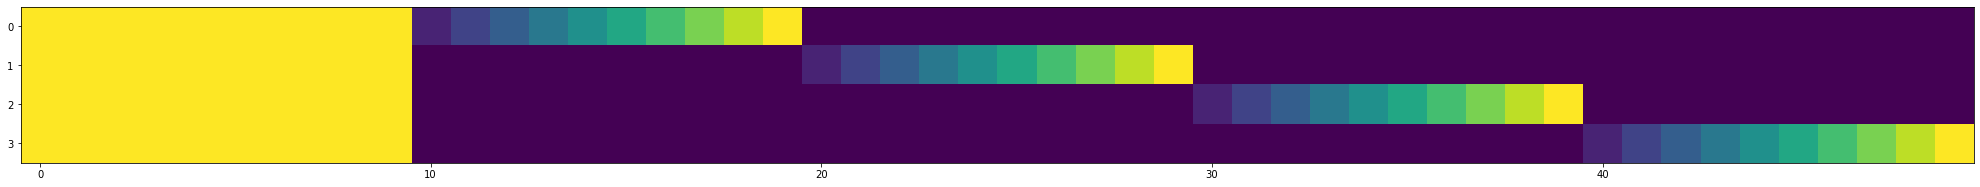

In [29]:
seq_class = []
total_tokens = 50
offset = 10 

for i in range(4):
    temp = np.zeros(total_tokens)
    temp[:offset] = 1
    temp[(i+1)*offset:((i+2)*offset)] = np.arange(0.1,1.1,0.1)
    temp = temp/sum(temp)
    seq_class.append(temp)
    assert(sum(seq_class[i])==1)
plt.figure(figsize=(35,10))
plt.imshow(np.vstack(seq_class))
    
def sample_sequence(next_token,seq_len):
    '''
    function to sample a sequence based on p(l|m,n) for given m and n.
    '''
    query_tokens = [5,6,7,8]
    next_tokens = [1,2,3,4]
    if next_token==next_tokens[0]:
        context_tokens = np.random.choice(np.arange(50),p=seq_class[0],size=seq_len-2)
        seq = np.append(context_tokens,[query_tokens[0],next_token])
    if next_token==next_tokens[1]:
        context_tokens = np.random.choice(np.arange(50),p=seq_class[1],size=seq_len-2)
        seq = np.append(context_tokens,[query_tokens[1],next_token])
    if next_token==next_tokens[2]:
        context_tokens = np.random.choice(np.arange(50),p=seq_class[2],size=seq_len-2)
        seq = np.append(context_tokens,[query_tokens[2],next_token])
    if next_token==next_tokens[3]:
        context_tokens = np.random.choice(np.arange(50),p=seq_class[3],size=seq_len-2)
        seq = np.append(context_tokens,[query_tokens[3],next_token])
    return seq

def generate_data(batch_size,seq_len):
    batch_of_seq = []
    next_tokens = [1,2,3,4]
    for i in range(batch_size):
        next_token = np.random.choice(next_tokens,p=[0.25]*4)
        generated_seq = sample_sequence(next_token,seq_len)
        batch_of_seq.append(torch.tensor(generated_seq))
    return torch.vstack(batch_of_seq)


def analyse_model(model,batch_size,seq_len):
    test_inputs = generate_data(batch_size,seq_len)
    tinputs,tlabels  = test_inputs[:,:-1].to(device),test_inputs[:,-1].to(device)
    
    model.eval()
    with torch.no_grad():
        model_output,model_attention = model(tinputs)
    #model_output = nn.Softmax(dim=1)(model_output)

    common_tokens_attn = []
    distinct_tokens_attn = []
    for i in range(batch_size):
        indices_1 = torch.logical_and(tinputs[i]>=0,tinputs[i]<10)
        indices_2 = torch.logical_and(tinputs[i]>=10,tinputs[i]<50)
        common_tokens_attn.append(sum(model_attention[i][indices_1]).item())
        distinct_tokens_attn.append(sum(model_attention[i][indices_2]).item())
    return np.mean(common_tokens_attn),np.mean(distinct_tokens_attn)


class Net_p1(nn.Module):
    def __init__(self):
        super(Net_p1,self).__init__()
        self.key_layer = nn.Linear(50,50,bias=False)
        self.query_layer = nn.Linear(50,50,bias=False)
        self.value_layer = nn.Linear(50,50,bias=False)
        self.prediction_layer = nn.Linear(50,50,bias=False)
        
        #self.key_layer.weight = nn.Parameter(torch.eye(50,50)*0.000001)
        #self.query_layer.weight = nn.Parameter(torch.eye(50,50)*0.000001)
        self.value_layer.weight = nn.Parameter(torch.eye(50,50)*0.000001)
        self.prediction_layer.weight = nn.Parameter(torch.eye(50,50)*0.000001)
    def forward(self,x):
        batch,seq_len,vocab_size = x.shape
        
        key = self.key_layer(x)
        query = torch.unsqueeze(self.query_layer(x[:,-1]),dim=1)
        
        #print(key.shape,query.shape)
        scores = (query@key.transpose(-2,-1))*(1/math.sqrt(key.size(-1)))
        
        
        
        
        attn = nn.Softmax(dim=-1)(scores)
        x1 = self.value_layer(x)
        context =torch.matmul(attn,x1)
    
        output = self.prediction_layer(context)
        #print(output.shape)
        return output[:,0,:],attn[:,0,:]
    
class Net_p2(nn.Module):
    def __init__(self):
        super(Net_p2,self).__init__()
        self.key_layer = nn.Linear(50,50,bias=False)
        self.query_layer = nn.Linear(50,50,bias=False)
        #self.value_layer = nn.Linear(50,50,bias=False)
        self.prediction_layer = nn.Linear(50,50,bias=False)
        
        #self.key_query_layer.weight = nn.Parameter(torch.zeros(50,50))
        self.key_layer.weight = nn.Parameter(torch.eye(50,50)*0.000001)
        self.query_layer.weight = nn.Parameter(torch.eye(50,50)*0.000001)
        #self.value_layer.weight = nn.Parameter(torch.eye(50,50)*0.000001)
        self.prediction_layer.weight = nn.Parameter(torch.eye(50,50)*0.000001)
    def forward(self,x):
        batch,seq_len,vocab_size = x.shape
        
        key = self.key_layer(x)
        query = torch.unsqueeze(self.query_layer(x[:,-1]),dim=1)
        
        #print(key.shape,query.shape)
        scores = (query@key.transpose(-2,-1))*(1/math.sqrt(key.size(-1)))
        
        
        
        
        attn = nn.Softmax(dim=-1)(scores)
        x1 = x #self.value_layer(x)
        context =torch.matmul(attn,x1)
    
        output = self.prediction_layer(context)
        #print(output.shape)
        return output[:,0,:],attn[:,0,:]



In [30]:
def generate_heatmap(model,epoch_no):
    model.eval()
    attn_values = []
    prediction  = []
    with torch.no_grad():
        running_loss = 0.0
        for j in range(200):
            data = generate_data(batch_size,seq_len)
            inputs,labels = data[:,:-1].to(device),data[:,-1].to(device)
            indices = inputs>9
            inputs = F.one_hot(inputs,num_classes=50).float()
            outputs,attn  = model(inputs)
            #print(outputs.shape)
            outputs = nn.Softmax(dim=1)(outputs)
            #print(outputs[np.arange(128),labels])
            #print(outputs.shape)

            for i in range(outputs.shape[0]):
                attn_values.append(sum(attn[i][indices[i]]).item())
                prediction.append(outputs[i,labels[i]].item())
    return attn_values,prediction

## FAFO

In [31]:
n_epochs = 2500
n_batches = 250

batch_size= 32 # actual batch size is times 4 here 128
seq_len = 64

n_seeds = [1234]#ß,1235,1236]

Attn_Values  = []
Prediction_Values = []
#deltas_list = []
for seed in n_seeds:
    torch.manual_seed(seed)
    model_1 = Net_p1().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model_1.parameters(),lr=1e-2)

    running_loss = 0.0

    common_token_attn = []
    distinct_token_attn = []
    #deltas = []
    epsilon = 1e-8
    #generate_heatmap(model,0)
    for epoch in tqdm(range(n_epochs)):
        model_1.train()
        # record conservation error
#         with torch.no_grad():
#             C1 = model.value_layer.weight.matmul(model.value_layer.weight.t())
#             C2 = model.prediction_layer.weight.t().matmul(model.prediction_layer.weight)
            
#             denom = max(torch.norm(C1).item(), torch.norm(C2).item(), epsilon)
#             delta = torch.norm(C2 - C1).item() / denom
#             deltas.append(delta)
        for j in range(n_batches):
            data = generate_data(batch_size,seq_len)

            inputs,labels = data[:,:-1].to(device),data[:,-1].to(device)
            inputs = F.one_hot(inputs,num_classes=50).float()

            optimizer.zero_grad()

            outputs,_ = model_1(inputs)
            loss = criterion(outputs,labels)
            loss.backward()
            optimizer.step()
            running_loss +=loss.item()
        if (running_loss/n_batches)<=0.001:
            break
        if (epoch+1)%100 ==0:
            print(f'[{epoch+1},{j+1:5d}] loss:{running_loss/(100*n_batches):.3f}')
            running_loss = 0.0
            #generate_heatmap(model,epoch+1)
    print("Finished Training")
    #deltas_list.append(deltas)
    attn,preds = generate_heatmap(model_1,epoch+1)
    Attn_Values.append(attn)
    Prediction_Values.append(preds)

  4%|█▌                                      | 100/2500 [01:18<31:28,  1.27it/s]

[100,  250] loss:2.901


  8%|███▏                                    | 200/2500 [02:36<29:57,  1.28it/s]

[200,  250] loss:1.310


 12%|████▊                                   | 300/2500 [03:54<28:28,  1.29it/s]

...

[1000,  250] loss:0.001


 44%|█████████████████▏                     | 1100/2500 [14:18<17:57,  1.30it/s]

[1100,  250] loss:0.001


 44%|█████████████████▏                     | 1100/2500 [14:19<18:13,  1.28it/s]


Finished Training


In [32]:
correct = 0 
total = 0
model_1.eval()
with torch.no_grad():
    running_loss = 0.0 
    for j in range(500):
        data = generate_data(batch_size,seq_len)
        inputs,labels = data[:,:-1].to(device),data[:,-1].to(device)
        inputs = F.one_hot(inputs,num_classes=50).float()
        outputs,attn  = model_1(inputs)
        loss = criterion(outputs,labels)
        running_loss +=loss.item()
        correct += sum(outputs.max(1)[1]==labels).item()
        total += len(labels)
print(f'loss:{running_loss/(j+1):.3f}')
print(f'accuracy:{correct/total:.3f}')

loss:0.001
accuracy:1.000


In [33]:
attn_values_1 = np.mean(Attn_Values,axis=0)
prediction_1 = np.mean(Prediction_Values,axis=0)

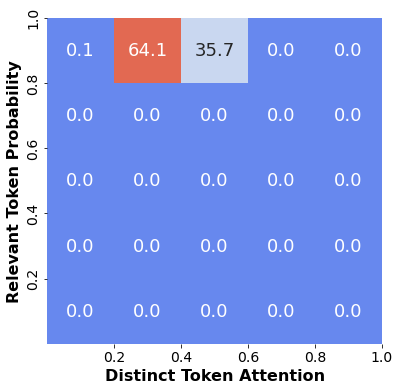

In [34]:
bin_edges = [np.array([0, 0.2, 0.4, 0.6, 0.8, 1]), np.array([0, 0.2, 0.4, 0.6, 0.8, 1])]

num = 64
histograms = []
for attn_values, prediction in zip(Attn_Values, Prediction_Values):
    hist, _, _ = np.histogram2d(attn_values, prediction, bins=bin_edges)
    histograms.append(hist)
    
# Stack and compute mean and variance
histograms = np.stack(histograms)
mean_hist = np.mean(histograms, axis=0)
var_hist = np.var(histograms, axis=0)


mean_hist_norm = np.round(mean_hist/num,1)


# Assuming `mean_hist_norm` and `var_hist_norm` are your 2D arrays of the same shape
# If you prefer to show std instead of variance in the annotation, convert variance to std:
std_hist_norm = np.round(np.sqrt(var_hist/num), 1)  # If you want std, otherwise use var_hist for variance.

# Create annotation labels with both mean and std (formatted as strings)
annot_array = np.empty_like(mean_hist_norm, dtype=object)
for i in range(mean_hist_norm.shape[0]):
    for j in range(mean_hist_norm.shape[1]):
        annot_array[i, j] = f"{mean_hist_norm[i, j]:.1f}"#\n(±{std_hist_norm[i, j]:.1f})"  # mean ± std

# Define tick positions for edges of bins (for correct labeling)
x_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
y_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
xtick_positions = np.arange(len(x_edges) - 1) + 1.0  # Right edges
ytick_positions = np.arange(len(y_edges) - 1) + 1.0  # Top edges

# Plot heatmap for mean values (color intensity)
plt.figure(figsize=(6, 6))
ax = sns.heatmap(mean_hist_norm.T, annot=annot_array.T, cmap=sns.color_palette("coolwarm"), 
                 annot_kws={"size":18}, cbar=False, vmin=5, vmax=70,fmt="")

# Adjust tick positions for x and y axes (move them to the edges)
ax.set_xticks(xtick_positions)
ax.set_yticks(ytick_positions)

# Set the labels for ticks (x and y edges)
ax.set_xticklabels(x_edges[1:])
ax.set_yticklabels(y_edges[1:])

# Make the tick labels bold
ax.tick_params(axis='x', labelsize=14)  # Bold x-axis labels
ax.tick_params(axis='y', labelsize=14)  # Bold y-axis labels


# Invert y-axis to align with typical heatmap style
ax.invert_yaxis()

# Labels and title
plt.xlabel(r"Distinct Token Attention", fontweight="bold", fontsize=16)
plt.ylabel(r"Relevant Token Probability", fontweight="bold", fontsize=16)
#plt.title("Mean (±Std Dev) Heatmap")

# Save the figure
plt.savefig("Params1.pdf", bbox_inches='tight')
plt.show()


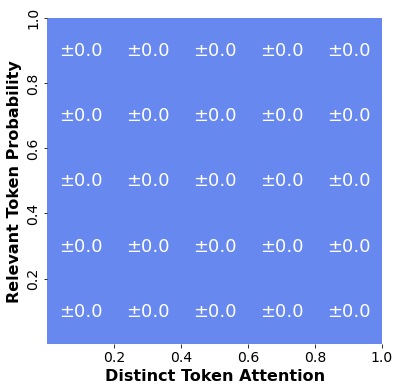

In [35]:
# Create annotation labels with both mean and std (formatted as strings)
annot_array = np.empty_like(std_hist_norm, dtype=object)
for i in range(std_hist_norm.shape[0]):
    for j in range(std_hist_norm.shape[1]):
        annot_array[i, j] = f"±{std_hist_norm[i, j]:.1f}"  # mean ± std

# Define tick positions for edges of bins (for correct labeling)
x_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
y_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
xtick_positions = np.arange(len(x_edges) - 1) + 1.0  # Right edges
ytick_positions = np.arange(len(y_edges) - 1) + 1.0  # Top edges

# Plot heatmap for mean values (color intensity)
plt.figure(figsize=(6, 6))
ax = sns.heatmap(std_hist_norm.T, annot=annot_array.T, cmap=sns.color_palette("coolwarm"), 
                 annot_kws={"size":18}, cbar=False, vmin=5, vmax=70,fmt="")

# Adjust tick positions for x and y axes (move them to the edges)
ax.set_xticks(xtick_positions)
ax.set_yticks(ytick_positions)

# Set the labels for ticks (x and y edges)
ax.set_xticklabels(x_edges[1:])
ax.set_yticklabels(y_edges[1:])

# Make the tick labels bold
ax.tick_params(axis='x', labelsize=14)  # Bold x-axis labels
ax.tick_params(axis='y', labelsize=14)  # Bold y-axis labels


# Invert y-axis to align with typical heatmap style
ax.invert_yaxis()

# Labels and title
plt.xlabel(r"Distinct Token Attention", fontweight="bold", fontsize=16)
plt.ylabel(r"Relevant Token Probability", fontweight="bold", fontsize=16)
#plt.title("Mean (±Std Dev) Heatmap")

# Save the figure
plt.savefig("Params1_std.pdf", bbox_inches='tight')
plt.show()


In [38]:
separability = []
with torch.no_grad():
    for j in range(200):
        data = generate_data(batch_size,seq_len)
        inputs,labels = data[:,:-1].to(device),data[:,-1].to(device)
        indices = inputs>9
        inputs = F.one_hot(inputs,num_classes=50).float()
        outputs,attn  = model_1(inputs)
        #print(outputs.shape)
        #outputs = nn.Softmax(dim=1)(outputs)
        #print(outputs[np.arange(128),labels])
        #print(outputs.shape)
        
        #print(outputs.shape,attn.shape)
        
        for i in range(outputs.shape[0]):
            
            #print(attn[i],labels[i],indices[i]
                  
            max_value = torch.max(attn[i][indices[i]]).item()
            min_value = torch.min(attn[i][~indices[i]]).item()
            #prediction.append(outputs[i,labels[i]].item())
            
            separability.append(max_value-min_value)


In [41]:
np.array(separability).mean()

0.0035905217997787985

In [43]:
# torch.manual_seed(1234)
# model = Net_p1().to(device)
model_1.eval()
attn_values = []
prediction  = []
with torch.no_grad():
    running_loss = 0.0
    for j in range(500):
        data = generate_data(batch_size,seq_len)
        inputs,labels = data[:,:-1].to(device),data[:,-1].to(device)
        indices = inputs>9
        inputs = F.one_hot(inputs,num_classes=50).float()
        outputs,attn  = model_1(inputs)
        #print(outputs.shape)
        outputs = nn.Softmax(dim=1)(outputs)
        #print(outputs[np.arange(128),labels])
        
        for i in range(attn.shape[0]):
            attn_values.append(sum(attn[i][indices[i]]).item())
            prediction.append(outputs[i,labels[i]].item())


In [44]:
attn_values = np.array(attn_values)[None,:]
prediction = np.array(prediction)[None,:]

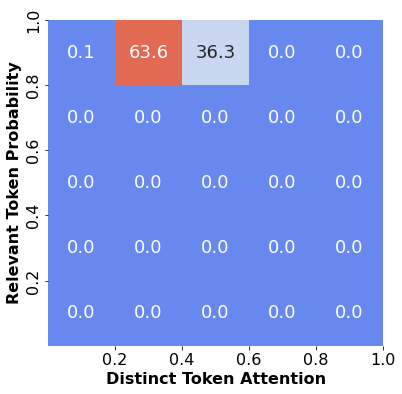

In [45]:
num = 160
histograms = []
for attn, pred in zip(attn_values, prediction):
    hist, _, _ = np.histogram2d(attn, pred, bins=bin_edges)
    histograms.append(hist)
    
# Stack and compute mean and variance
histograms = np.stack(histograms)
mean_hist = np.mean(histograms, axis=0)
var_hist = np.var(histograms, axis=0)


mean_hist_norm = np.round(mean_hist/num,1)


# Assuming `mean_hist_norm` and `var_hist_norm` are your 2D arrays of the same shape
# If you prefer to show std instead of variance in the annotation, convert variance to std:
std_hist_norm = np.round(np.sqrt(var_hist/num), 1)  # If you want std, otherwise use var_hist for variance.

# Create annotation labels with both mean and std (formatted as strings)
annot_array = np.empty_like(mean_hist_norm, dtype=object)
for i in range(mean_hist_norm.shape[0]):
    for j in range(mean_hist_norm.shape[1]):
        annot_array[i, j] = f"{mean_hist_norm[i, j]:.1f}" #\n(±{std_hist_norm[i, j]:.1f})"  # mean ± std

# Define tick positions for edges of bins (for correct labeling)
x_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
y_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
xtick_positions = np.arange(len(x_edges) - 1) + 1.0  # Right edges
ytick_positions = np.arange(len(y_edges) - 1) + 1.0  # Top edges

# Plot heatmap for mean values (color intensity)
plt.figure(figsize=(6, 6))
ax = sns.heatmap(mean_hist_norm.T, annot=annot_array.T, cmap=sns.color_palette("coolwarm"), 
                 annot_kws={"size":18}, cbar=False, vmin=5, vmax=70,fmt="")

# Adjust tick positions for x and y axes (move them to the edges)
ax.set_xticks(xtick_positions)
ax.set_yticks(ytick_positions)

# Set the labels for ticks (x and y edges)
ax.set_xticklabels(x_edges[1:])
ax.set_yticklabels(y_edges[1:])

# Make the tick labels bold
ax.tick_params(axis='x', labelsize=16)  # Bold x-axis labels
ax.tick_params(axis='y', labelsize=16)  # Bold y-axis labels


# Invert y-axis to align with typical heatmap style
ax.invert_yaxis()

# Labels and title
plt.xlabel(r"Distinct Token Attention", fontweight="bold", fontsize=16)
plt.ylabel(r"Relevant Token Probability", fontweight="bold", fontsize=16)
#plt.title("Mean (±Std Dev) Heatmap")

# Save the figure
plt.savefig("Params1_test.pdf", bbox_inches='tight')
plt.show()


## FACO

In [46]:
n_epochs = 2500
n_batches = 250

batch_size= 32 # actual batch size is times 4 here 128
seq_len = 64

n_seeds = [1234]#,1235,1236]

Attn_Values  = []
Prediction_Values = []
#deltas_list = []
for seed in n_seeds:
    torch.manual_seed(seed)
    model_2 = Net_p2().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model_2.parameters(),lr=1e-2)

    running_loss = 0.0

    common_token_attn = []
    distinct_token_attn = []
    #deltas = []
    epsilon = 1e-8
    #generate_heatmap(model,0)
    for epoch in tqdm(range(n_epochs)):
        model_2.train()
        # record conservation error
#         with torch.no_grad():
#             C1 = model.value_layer.weight.matmul(model.value_layer.weight.t())
#             C2 = model.prediction_layer.weight.t().matmul(model.prediction_layer.weight)
            
#             denom = max(torch.norm(C1).item(), torch.norm(C2).item(), epsilon)
#             delta = torch.norm(C2 - C1).item() / denom
#             deltas.append(delta)
        for j in range(n_batches):
            data = generate_data(batch_size,seq_len)

            inputs,labels = data[:,:-1].to(device),data[:,-1].to(device)
            inputs = F.one_hot(inputs,num_classes=50).float()

            optimizer.zero_grad()

            outputs,_ = model_2(inputs)
            loss = criterion(outputs,labels)
            loss.backward()
            optimizer.step()
            running_loss +=loss.item()
        if (running_loss/n_batches)<=0.001:
            break
        if (epoch+1)%100 ==0:
            print(f'[{epoch+1},{j+1:5d}] loss:{running_loss/(100*n_batches):.3f}')
            running_loss = 0.0
            #generate_heatmap(model,epoch+1)
    print("Finished Training")
    #deltas_list.append(deltas)
    attn,preds = generate_heatmap(model_2,epoch+1)
    Attn_Values.append(attn)
    Prediction_Values.append(preds)

  4%|█▌                                      | 100/2500 [01:11<28:22,  1.41it/s]

[100,  250] loss:2.522


  8%|███▏                                    | 200/2500 [02:22<27:17,  1.40it/s]

[200,  250] loss:1.030


 12%|████▊                                   | 300/2500 [03:33<25:57,  1.41it/s]

...

[2300,  250] loss:0.002


 96%|█████████████████████████████████████▍ | 2400/2500 [28:27<01:10,  1.42it/s]

[2400,  250] loss:0.001


100%|███████████████████████████████████████| 2500/2500 [29:42<00:00,  1.40it/s]

[2500,  250] loss:0.001
Finished Training


In [47]:
# plt.plot(deltas_list[2])
# plt.ylabel(r"$\Delta$")
# plt.xlabel("epochs")
# plt.savefig("conserve_quantity.pdf")

In [49]:
correct = 0 
total = 0
model_2.eval()
with torch.no_grad():
    running_loss = 0.0 
    for j in range(500):
        data = generate_data(batch_size,seq_len)
        inputs,labels = data[:,:-1].to(device),data[:,-1].to(device)
        inputs = F.one_hot(inputs,num_classes=50).float()
        outputs,attn  = model_2(inputs)
        loss = criterion(outputs,labels)
        running_loss +=loss.item()
        correct += sum(outputs.max(1)[1]==labels).item()
        total += len(labels)
print(f'loss:{running_loss/(j+1):.3f}')
print(f'accuracy:{correct/total:.3f}')

loss:0.001
accuracy:1.000


In [50]:
#  sum(((np.array(Attn_Values[0]) + np.array(Attn_Values[1]) +  
#        np.array(Attn_Values[2]) +  np.array(Attn_Values[3]) +  
#        np.array(Attn_Values[4]) ) /5)>=0.4)

In [51]:
#generate_heatmap(model,epoch+1)

In [52]:
attn_values_1 = np.mean(Attn_Values,axis=0)
prediction_1 = np.mean(Prediction_Values,axis=0)

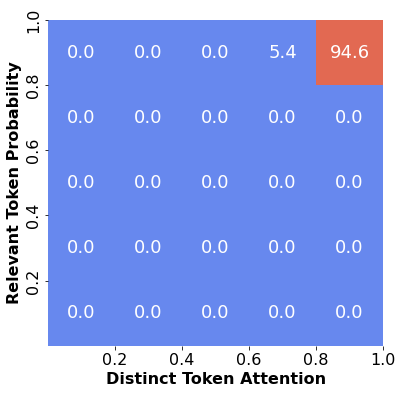

In [53]:
bin_edges = [np.array([0, 0.2, 0.4, 0.6, 0.8, 1]), np.array([0, 0.2, 0.4, 0.6, 0.8, 1])]

num = 64
histograms = []
for attn_values, prediction in zip(Attn_Values, Prediction_Values):
    hist, _, _ = np.histogram2d(attn_values, prediction, bins=bin_edges)
    histograms.append(hist)
    
# Stack and compute mean and variance
histograms = np.stack(histograms)
mean_hist = np.mean(histograms, axis=0)
var_hist = np.var(histograms, axis=0)


mean_hist_norm = np.round(mean_hist/num,1)


# Assuming `mean_hist_norm` and `var_hist_norm` are your 2D arrays of the same shape
# If you prefer to show std instead of variance in the annotation, convert variance to std:
std_hist_norm = np.round(np.sqrt(var_hist/num), 1)  # If you want std, otherwise use var_hist for variance.

# Create annotation labels with both mean and std (formatted as strings)
annot_array = np.empty_like(mean_hist_norm, dtype=object)
for i in range(mean_hist_norm.shape[0]):
    for j in range(mean_hist_norm.shape[1]):
        annot_array[i, j] = f"{mean_hist_norm[i, j]:.1f}"#\n(±{std_hist_norm[i, j]:.1f})"  # mean ± std

# Define tick positions for edges of bins (for correct labeling)
x_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
y_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
xtick_positions = np.arange(len(x_edges) - 1) + 1.0  # Right edges
ytick_positions = np.arange(len(y_edges) - 1) + 1.0  # Top edges

# Plot heatmap for mean values (color intensity)
plt.figure(figsize=(6, 6))
ax = sns.heatmap(mean_hist_norm.T, annot=annot_array.T, cmap=sns.color_palette("coolwarm"), 
                 annot_kws={"size":18}, cbar=False, vmin=5, vmax=70,fmt="")

# Adjust tick positions for x and y axes (move them to the edges)
ax.set_xticks(xtick_positions)
ax.set_yticks(ytick_positions)

# Set the labels for ticks (x and y edges)
ax.set_xticklabels(x_edges[1:])
ax.set_yticklabels(y_edges[1:])

# Make the tick labels bold
ax.tick_params(axis='x', labelsize=16)  # Bold x-axis labels
ax.tick_params(axis='y', labelsize=16)  # Bold y-axis labels


# Invert y-axis to align with typical heatmap style
ax.invert_yaxis()

# Labels and title
plt.xlabel(r"Distinct Token Attention", fontweight="bold", fontsize=16)
plt.ylabel(r"Relevant Token Probability", fontweight="bold", fontsize=16)
#plt.title("Mean (±Std Dev) Heatmap")

# Save the figure
plt.savefig("Params2.pdf", bbox_inches='tight')
plt.show()


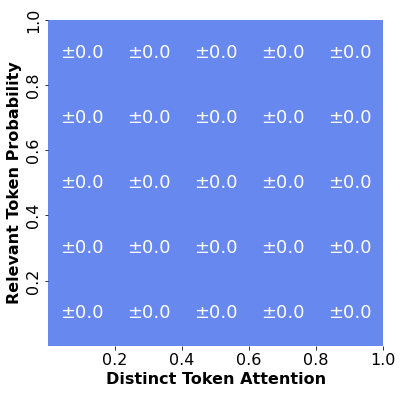

In [54]:
# Create annotation labels with both mean and std (formatted as strings)
annot_array = np.empty_like(std_hist_norm, dtype=object)
for i in range(std_hist_norm.shape[0]):
    for j in range(std_hist_norm.shape[1]):
        annot_array[i, j] = f"±{std_hist_norm[i, j]:.1f}"  # mean ± std

# Define tick positions for edges of bins (for correct labeling)
x_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
y_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
xtick_positions = np.arange(len(x_edges) - 1) + 1.0  # Right edges
ytick_positions = np.arange(len(y_edges) - 1) + 1.0  # Top edges

# Plot heatmap for mean values (color intensity)
plt.figure(figsize=(6, 6))
ax = sns.heatmap(std_hist_norm.T, annot=annot_array.T, cmap=sns.color_palette("coolwarm"), 
                 annot_kws={"size":18}, cbar=False, vmin=5, vmax=70,fmt="")

# Adjust tick positions for x and y axes (move them to the edges)
ax.set_xticks(xtick_positions)
ax.set_yticks(ytick_positions)

# Set the labels for ticks (x and y edges)
ax.set_xticklabels(x_edges[1:])
ax.set_yticklabels(y_edges[1:])

# Make the tick labels bold
ax.tick_params(axis='x', labelsize=16)  # Bold x-axis labels
ax.tick_params(axis='y', labelsize=16)  # Bold y-axis labels


# Invert y-axis to align with typical heatmap style
ax.invert_yaxis()

# Labels and title
plt.xlabel(r"Distinct Token Attention", fontweight="bold", fontsize=16)
plt.ylabel(r"Relevant Token Probability", fontweight="bold", fontsize=16)
#plt.title("Mean (±Std Dev) Heatmap")

# Save the figure
plt.savefig("Params2_std.pdf", bbox_inches='tight')
plt.show()


In [58]:
# torch.manual_seed(1234)
# model = Net_p1().to(device)
model_2.eval()
attn_values = []
prediction  = []
with torch.no_grad():
    running_loss = 0.0
    for j in range(500):
        data = generate_data(batch_size,seq_len)
        inputs,labels = data[:,:-1].to(device),data[:,-1].to(device)
        indices = inputs>9
        inputs = F.one_hot(inputs,num_classes=50).float()
        outputs,attn  = model_2(inputs)
        #print(outputs.shape)
        outputs = nn.Softmax(dim=1)(outputs)
        #print(outputs[np.arange(128),labels])
        
        for i in range(attn.shape[0]):
            attn_values.append(sum(attn[i][indices[i]]).item())
            prediction.append(outputs[i,labels[i]].item())


In [59]:
128*500, len(attn_values), len(prediction),

(64000, 16000, 16000)

In [60]:
attn_values = np.array(attn_values)[None,:]
prediction = np.array(prediction)[None,:]

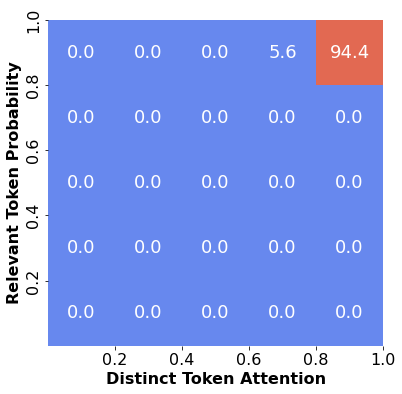

In [61]:
num = 160
histograms = []
for attn, pred in zip(attn_values, prediction):
    hist, _, _ = np.histogram2d(attn, pred, bins=bin_edges)
    histograms.append(hist)
    
# Stack and compute mean and variance
histograms = np.stack(histograms)
mean_hist = np.mean(histograms, axis=0)
var_hist = np.var(histograms, axis=0)


mean_hist_norm = np.round(mean_hist/num,1)


# Assuming `mean_hist_norm` and `var_hist_norm` are your 2D arrays of the same shape
# If you prefer to show std instead of variance in the annotation, convert variance to std:
std_hist_norm = np.round(np.sqrt(var_hist/num), 1)  # If you want std, otherwise use var_hist for variance.

# Create annotation labels with both mean and std (formatted as strings)
annot_array = np.empty_like(mean_hist_norm, dtype=object)
for i in range(mean_hist_norm.shape[0]):
    for j in range(mean_hist_norm.shape[1]):
        annot_array[i, j] = f"{mean_hist_norm[i, j]:.1f}" #\n(±{std_hist_norm[i, j]:.1f})"  # mean ± std

# Define tick positions for edges of bins (for correct labeling)
x_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
y_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
xtick_positions = np.arange(len(x_edges) - 1) + 1.0  # Right edges
ytick_positions = np.arange(len(y_edges) - 1) + 1.0  # Top edges

# Plot heatmap for mean values (color intensity)
plt.figure(figsize=(6, 6))
ax = sns.heatmap(mean_hist_norm.T, annot=annot_array.T, cmap=sns.color_palette("coolwarm"), 
                 annot_kws={"size":18}, cbar=False, vmin=5, vmax=70,fmt="")

# Adjust tick positions for x and y axes (move them to the edges)
ax.set_xticks(xtick_positions)
ax.set_yticks(ytick_positions)

# Set the labels for ticks (x and y edges)
ax.set_xticklabels(x_edges[1:])
ax.set_yticklabels(y_edges[1:])

# Make the tick labels bold
ax.tick_params(axis='x', labelsize=16)  # Bold x-axis labels
ax.tick_params(axis='y', labelsize=16)  # Bold y-axis labels


# Invert y-axis to align with typical heatmap style
ax.invert_yaxis()

# Labels and title
plt.xlabel(r"Distinct Token Attention", fontweight="bold", fontsize=16)
plt.ylabel(r"Relevant Token Probability", fontweight="bold", fontsize=16)
#plt.title("Mean (±Std Dev) Heatmap")

# Save the figure
plt.savefig("Params2_test.pdf", bbox_inches='tight')
plt.show()


In [62]:


# num =160


# plt.figure(figsize=(6,6))
# im = plt.hist2d(np.array(attn_values),np.array(prediction),[[0,0.2,0.4,0.6,0.8,1],[0,0.2,0.4,0.6,0.8,1]])


# ax = sns.heatmap(np.round(im[0].transpose()/num,1),vmin=5,vmax=70,annot=True,fmt="g",cmap=sns.color_palette("coolwarm"),
#                  yticklabels=[0.2,0.4,0.6,0.8,1.],
#                  xticklabels=[0.2,0.4,0.6,0.8,1],annot_kws={"size":18},cbar=False)
# ax.invert_yaxis()

# plt.xlabel(r"distinct token attention",fontweight="bold",fontsize=20)
# plt.ylabel(r"true token probability",fontweight="bold",fontsize=20) # change xlabel based on algo
# # plt.xticks([1,2,3,4,5],weight="bold",fontsize=18)
# # plt.yticks([1,2,3,4,5],weight="bold", va="top",fontsize=18)
# plt.savefig("heatmap_Setting_1_len_"+str(seq_len)+".pdf",bbox_inches='tight')

In [ ]:
# import numpy as np    
# hist, bin_edges = np.histogram(attn_values, bins = [0,0.2,0.4,0.6,0.8,1])

In [ ]:
# hist,bin_edges

In [ ]:
# 7697+8278+12+13

In [ ]:
# temp_1 = model.value_layer.weight.cpu().detach().numpy()
# temp_2 = model.prediction_layer.weight.cpu().detach().numpy()

In [ ]:
# U1,S1,V1 = np.linalg.svd(temp_1)
# U2,S2,V2 = np.linalg.svd(temp_2)

In [ ]:
# V1.T[:,4]@U2[:,4]

In [ ]:
# S2

In [ ]:
# S1

In [66]:
separability_1 = []
separability_2 = []
with torch.no_grad():
    for j in range(200):
        data = generate_data(batch_size,seq_len)
        inputs,labels = data[:,:-1].to(device),data[:,-1].to(device)
        indices = inputs>9
        inputs = F.one_hot(inputs,num_classes=50).float()
        
        outputs_1, attn_1 = model_1(inputs)
        outputs_2, attn_2 = model_2(inputs)

        
        for i in range(outputs_1.shape[0]):
            
            #print(attn[i],labels[i],indices[i]
                  
            max_value = torch.max(attn_1[i][indices[i]]).item()
            min_value = torch.min(attn_1[i][~indices[i]]).item()
            #prediction.append(outputs[i,labels[i]].item())
            
            separability_1.append(max_value-min_value)
            
        for i in range(outputs_2.shape[0]):
            
            #print(attn[i],labels[i],indices[i]
                  
            max_value = torch.max(attn_2[i][indices[i]]).item()
            min_value = torch.min(attn_2[i][~indices[i]]).item()
            #prediction.append(outputs[i,labels[i]].item())
            
            separability_2.append(max_value-min_value)



In [67]:
np.array(separability_1).mean(), np.std(np.array(separability_1))

(0.0036011230207805057, 0.0006917548140273317)

In [68]:
np.array(separability_2).mean(), np.std(np.array(separability_2))

(0.10556412973190163, 0.022467949260446995)

## CAFO

In [ ]:
class Net_p3(nn.Module):
    def __init__(self):
        super(Net_p3,self).__init__()
        self.key_query_layer = nn.Linear(50,50,bias=False)
        #self.query_layer = nn.Linear(50,50,bias=False)
        self.value_layer = nn.Linear(50,50,bias=False)
        self.prediction_layer = nn.Linear(50,50,bias=False)
        
        #self.key_query_layer.weight = nn.Parameter(torch.zeros(50,50))
        self.key_query_layer.weight = nn.Parameter(torch.eye(50,50)*0.000001)
        #self.query_layer.weight = nn.Parameter(torch.eye(50,50)*0.000001)
        self.value_layer.weight = nn.Parameter(torch.eye(50,50)*0.000001)
        self.prediction_layer.weight = nn.Parameter(torch.eye(50,50)*0.000001)
    def forward(self,x):
        batch,seq_len,vocab_size = x.shape
        
        key = self.key_query_layer(x)
        query = torch.unsqueeze(x[:,-1],dim=1)
        
        #print(key.shape,query.shape)
        scores = (query@key.transpose(-2,-1))*(1/math.sqrt(key.size(-1)))
        
        
        
        
        attn = nn.Softmax(dim=-1)(scores)
        x1 = self.value_layer(x)
        context =torch.matmul(attn,x1)
    
        output = self.prediction_layer(context)
        #print(output.shape)
        return output[:,0,:],attn[:,0,:]

In [ ]:
n_epochs = 5000
n_batches = 200

batch_size= 32 # actual batch size is times 4 here 128
seq_len = 64

n_seeds = [1234,1235,1236,1237,1238]

Attn_Values  = []
Prediction_Values = []
deltas_list = []
for seed in n_seeds:
    torch.manual_seed(seed)
    model = Net_p3().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(),lr=1e-2)

    running_loss = 0.0

    common_token_attn = []
    distinct_token_attn = []
    deltas = []
    epsilon = 1e-8
    #generate_heatmap(model,0)
    for epoch in tqdm(range(n_epochs)):
        model.train()
        # record conservation error
        with torch.no_grad():
            C1 = model.value_layer.weight.matmul(model.value_layer.weight.t())
            C2 = model.prediction_layer.weight.t().matmul(model.prediction_layer.weight)
            
            denom = max(torch.norm(C1).item(), torch.norm(C2).item(), epsilon)
            delta = torch.norm(C2 - C1).item() / denom
            deltas.append(delta)
        for j in range(n_batches):
            data = generate_data(batch_size,seq_len)

            inputs,labels = data[:,:-1].to(device),data[:,-1].to(device)
            inputs = F.one_hot(inputs,num_classes=50).float()

            optimizer.zero_grad()

            outputs,_ = model(inputs)
            loss = criterion(outputs,labels)
            loss.backward()
            optimizer.step()
            running_loss +=loss.item()
        if (running_loss/n_batches)<=0.001:
            break
        if (epoch+1)%100 ==0:
            print(f'[{epoch+1},{j+1:5d}] loss:{running_loss/(100*n_batches):.3f}')
            running_loss = 0.0
            #generate_heatmap(model,epoch+1)
    print("Finished Training")
    deltas_list.append(deltas)
    attn,preds = generate_heatmap(model,epoch+1)
    Attn_Values.append(attn)
    Prediction_Values.append(preds)

In [ ]:
plt.plot(deltas_list[2])
plt.ylabel(r"$\Delta$", fontweight="bold", fontsize=16)
plt.xlabel("epochs", fontweight="bold", fontsize=16)
plt.title(r"Conservation of W_O^{\top}W_O-W_VW_V^{\top}")
plt.savefig("conserve_quantity.pdf")


In [ ]:
correct = 0 
total = 0
model.eval()
with torch.no_grad():
    running_loss = 0.0 
    for j in range(500):
        data = generate_data(batch_size,seq_len)
        inputs,labels = data[:,:-1].to(device),data[:,-1].to(device)
        inputs = F.one_hot(inputs,num_classes=50).float()
        outputs,attn  = model(inputs)
        loss = criterion(outputs,labels)
        running_loss +=loss.item()
        correct += sum(outputs.max(1)[1]==labels).item()
        total += len(labels)
print(f'loss:{running_loss/(j+1):.3f}')
print(f'accuracy:{correct/total:.3f}')

In [ ]:
attn_values_1 = np.mean(Attn_Values,axis=0)
prediction_1 = np.mean(Prediction_Values,axis=0)

In [ ]:
bin_edges = [np.array([0, 0.2, 0.4, 0.6, 0.8, 1]), np.array([0, 0.2, 0.4, 0.6, 0.8, 1])]

num = 64
histograms = []
for attn_values, prediction in zip(Attn_Values, Prediction_Values):
    hist, _, _ = np.histogram2d(attn_values, prediction, bins=bin_edges)
    histograms.append(hist)
    
# Stack and compute mean and variance
histograms = np.stack(histograms)
mean_hist = np.mean(histograms, axis=0)
var_hist = np.var(histograms, axis=0)


mean_hist_norm = np.round(mean_hist/num,1)


# Assuming `mean_hist_norm` and `var_hist_norm` are your 2D arrays of the same shape
# If you prefer to show std instead of variance in the annotation, convert variance to std:
std_hist_norm = np.round(np.sqrt(var_hist/num), 1)  # If you want std, otherwise use var_hist for variance.

# Create annotation labels with both mean and std (formatted as strings)
annot_array = np.empty_like(mean_hist_norm, dtype=object)
for i in range(mean_hist_norm.shape[0]):
    for j in range(mean_hist_norm.shape[1]):
        annot_array[i, j] = f"{mean_hist_norm[i, j]:.1f}"#\n(±{std_hist_norm[i, j]:.1f})"  # mean ± std

# Define tick positions for edges of bins (for correct labeling)
x_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
y_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
xtick_positions = np.arange(len(x_edges) - 1) + 1.0  # Right edges
ytick_positions = np.arange(len(y_edges) - 1) + 1.0  # Top edges

# Plot heatmap for mean values (color intensity)
plt.figure(figsize=(6, 6))
ax = sns.heatmap(mean_hist_norm.T, annot=annot_array.T, cmap=sns.color_palette("coolwarm"), 
                 annot_kws={"size":18}, cbar=False, vmin=5, vmax=70,fmt="")

# Adjust tick positions for x and y axes (move them to the edges)
ax.set_xticks(xtick_positions)
ax.set_yticks(ytick_positions)

# Set the labels for ticks (x and y edges)
ax.set_xticklabels(x_edges[1:])
ax.set_yticklabels(y_edges[1:])

# Make the tick labels bold
ax.tick_params(axis='x', labelsize=16)  # Bold x-axis labels
ax.tick_params(axis='y', labelsize=16)  # Bold y-axis labels


# Invert y-axis to align with typical heatmap style
ax.invert_yaxis()

# Labels and title
plt.xlabel(r"Distinct Token Attention", fontweight="bold", fontsize=16)
plt.ylabel(r"Relevant Token Probability", fontweight="bold", fontsize=16)
#plt.title("Mean (±Std Dev) Heatmap")

# Save the figure
plt.savefig("Params3.pdf", bbox_inches='tight')
plt.show()


In [ ]:
# Create annotation labels with both mean and std (formatted as strings)
annot_array = np.empty_like(std_hist_norm, dtype=object)
for i in range(std_hist_norm.shape[0]):
    for j in range(std_hist_norm.shape[1]):
        annot_array[i, j] = f"±{std_hist_norm[i, j]:.1f}"  # mean ± std

# Define tick positions for edges of bins (for correct labeling)
x_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
y_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
xtick_positions = np.arange(len(x_edges) - 1) + 1.0  # Right edges
ytick_positions = np.arange(len(y_edges) - 1) + 1.0  # Top edges

# Plot heatmap for mean values (color intensity)
plt.figure(figsize=(6, 6))
ax = sns.heatmap(std_hist_norm.T, annot=annot_array.T, cmap=sns.color_palette("coolwarm"), 
                 annot_kws={"size":18}, cbar=False, vmin=5, vmax=70,fmt="")

# Adjust tick positions for x and y axes (move them to the edges)
ax.set_xticks(xtick_positions)
ax.set_yticks(ytick_positions)

# Set the labels for ticks (x and y edges)
ax.set_xticklabels(x_edges[1:])
ax.set_yticklabels(y_edges[1:])

# Make the tick labels bold
ax.tick_params(axis='x', labelsize=16)  # Bold x-axis labels
ax.tick_params(axis='y', labelsize=16)  # Bold y-axis labels


# Invert y-axis to align with typical heatmap style
ax.invert_yaxis()

# Labels and title
plt.xlabel(r"Distinct Token Attention", fontweight="bold", fontsize=16)
plt.ylabel(r"Relevant Token Probability", fontweight="bold", fontsize=16)
#plt.title("Mean (±Std Dev) Heatmap")

# Save the figure
plt.savefig("Params3_std.pdf", bbox_inches='tight')
plt.show()


In [ ]:
# torch.manual_seed(1234)
# model = Net_p1().to(device)
model.eval()
attn_values = []
prediction  = []
with torch.no_grad():
    running_loss = 0.0
    for j in range(500):
        data = generate_data(batch_size,seq_len)
        inputs,labels = data[:,:-1].to(device),data[:,-1].to(device)
        indices = inputs>9
        inputs = F.one_hot(inputs,num_classes=50).float()
        outputs,attn  = model(inputs)
        #print(outputs.shape)
        outputs = nn.Softmax(dim=1)(outputs)
        #print(outputs[np.arange(128),labels])
        
        for i in range(attn.shape[0]):
            attn_values.append(sum(attn[i][indices[i]]).item())
            prediction.append(outputs[i,labels[i]].item())


In [ ]:
attn_values = np.array(attn_values)[None,:]
prediction = np.array(prediction)[None,:]

In [ ]:
num = 160
histograms = []
for attn, pred in zip(attn_values, prediction):
    hist, _, _ = np.histogram2d(attn, pred, bins=bin_edges)
    histograms.append(hist)
    
# Stack and compute mean and variance
histograms = np.stack(histograms)
mean_hist = np.mean(histograms, axis=0)
var_hist = np.var(histograms, axis=0)


mean_hist_norm = np.round(mean_hist/num,1)


# Assuming `mean_hist_norm` and `var_hist_norm` are your 2D arrays of the same shape
# If you prefer to show std instead of variance in the annotation, convert variance to std:
std_hist_norm = np.round(np.sqrt(var_hist/num), 1)  # If you want std, otherwise use var_hist for variance.

# Create annotation labels with both mean and std (formatted as strings)
annot_array = np.empty_like(mean_hist_norm, dtype=object)
for i in range(mean_hist_norm.shape[0]):
    for j in range(mean_hist_norm.shape[1]):
        annot_array[i, j] = f"{mean_hist_norm[i, j]:.1f}" #\n(±{std_hist_norm[i, j]:.1f})"  # mean ± std

# Define tick positions for edges of bins (for correct labeling)
x_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])# Create annotation labels with both mean and std (formatted as strings)

y_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
xtick_positions = np.arange(len(x_edges) - 1) + 1.0  # Right edges
ytick_positions = np.arange(len(y_edges) - 1) + 1.0  # Top edges

# Plot heatmap for mean values (color intensity)
plt.figure(figsize=(6, 6))
ax = sns.heatmap(mean_hist_norm.T, annot=annot_array.T, cmap=sns.color_palette("coolwarm"), 
                 annot_kws={"size":18}, cbar=False, vmin=5, vmax=70,fmt="")

# Adjust tick positions for x and y axes (move them to the edges)
ax.set_xticks(xtick_positions)
ax.set_yticks(ytick_positions)

# Set the labels for ticks (x and y edges)
ax.set_xticklabels(x_edges[1:])
ax.set_yticklabels(y_edges[1:])

# Make the tick labels bold
ax.tick_params(axis='x', labelsize=16)  # Bold x-axis labels
ax.tick_params(axis='y', labelsize=16)  # Bold y-axis labels


# Invert y-axis to align with typical heatmap style
ax.invert_yaxis()

# Labels and title
plt.xlabel(r"Distinct Token Attention", fontweight="bold", fontsize=16)
plt.ylabel(r"Relevant Token Probability", fontweight="bold", fontsize=16)
#plt.title("Mean (±Std Dev) Heatmap")

# Save the figure
plt.savefig("Params3_test.pdf", bbox_inches='tight')
plt.show()


In [ ]:
with torch.no_grad():
    for j in range(200):
        data = generate_data(batch_size,seq_len)
        inputs,labels = data[:,:-1].to(device),data[:,-1].to(device)
        indices = inputs>9
        inputs = F.one_hot(inputs,num_classes=50).float()
        outputs,attn  = model(inputs)
        #print(outputs.shape)
        #outputs = nn.Softmax(dim=1)(outputs)
        #print(outputs[np.arange(128),labels])
        #print(outputs.shape)
        
        print(outputs.shape,attn.shape)
        
        for i in range(outputs.shape[0]):
            
            print(attn[i],labels[i],indices[i])
            attn_values.append(sum(attn[i][indices[i]]).item())
            print(attn_values[-1])
            break
            #prediction.append(outputs[i,labels[i]].item())


## CACO

In [ ]:
class Net_p4(nn.Module):
    def __init__(self):
        super(Net_p4,self).__init__()
        self.key_query_layer = nn.Linear(50,50,bias=False)

        self.prediction_layer = nn.Linear(50,50,bias=False)
        

#         self.key_query_layer.weight = nn.Parameter(torch.eye(50,50)*0.000001)
#         self.prediction_layer.weight = nn.Parameter(torch.eye(50,50)*0.000001)
    def forward(self,x):
        batch,seq_len,vocab_size = x.shape
        
        key = self.key_query_layer(x)
        query = torch.unsqueeze(x[:,-1],dim=1)
        
        #print(key.shape,query.shape)
        scores = (query@key.transpose(-2,-1))*(1/math.sqrt(key.size(-1)))
        
        
        
        
        attn = nn.Softmax(dim=-1)(scores)
        x1 = x #self.value_layer(x)
        context =torch.matmul(attn,x1)
    
        output = self.prediction_layer(context)
        #print(output.shape)
        return output[:,0,:],attn[:,0,:]

In [ ]:
n_epochs = 2500
n_batches = 200

batch_size= 32 # actual batch size is times 4 here 128
seq_len = 64

n_seeds = [1234,1235,1236]

Attn_Values  = []
Prediction_Values = []
#deltas_list = []
for seed in n_seeds:
    torch.manual_seed(seed)
    model = Net_p4().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(),lr=1e-2)

    running_loss = 0.0

    common_token_attn = []
    distinct_token_attn = []
    #deltas = []
    epsilon = 1e-8
    #generate_heatmap(model,0)
    for epoch in tqdm(range(n_epochs)):
        model.train()
        # record conservation error
#         with torch.no_grad():
#             C1 = model.value_layer.weight.matmul(model.value_layer.weight.t())
#             C2 = model.prediction_layer.weight.t().matmul(model.prediction_layer.weight)
            
#             denom = max(torch.norm(C1).item(), torch.norm(C2).item(), epsilon)
#             delta = torch.norm(C2 - C1).item() / denom
#             deltas.append(delta)
        for j in range(n_batches):
            data = generate_data(batch_size,seq_len)

            inputs,labels = data[:,:-1].to(device),data[:,-1].to(device)
            inputs = F.one_hot(inputs,num_classes=50).float()

            optimizer.zero_grad()

            outputs,_ = model(inputs)
            loss = criterion(outputs,labels)
            loss.backward()
            optimizer.step()
            running_loss +=loss.item()
        if (running_loss/n_batches)<=0.001:
            break
        if (epoch+1)%100 ==0:
            print(f'[{epoch+1},{j+1:5d}] loss:{running_loss/(100*n_batches):.3f}')
            running_loss = 0.0
            #generate_heatmap(model,epoch+1)
    print("Finished Training")
    #deltas_list.append(deltas)
    attn,preds = generate_heatmap(model,epoch+1)
    Attn_Values.append(attn)
    Prediction_Values.append(preds)

In [ ]:
correct = 0 
total = 0
model.eval()
with torch.no_grad():
    running_loss = 0.0 
    for j in range(500):
        data = generate_data(batch_size,seq_len)
        inputs,labels = data[:,:-1].to(device),data[:,-1].to(device)
        inputs = F.one_hot(inputs,num_classes=50).float()
        outputs,attn  = model(inputs)
        loss = criterion(outputs,labels)
        running_loss +=loss.item()
        correct += sum(outputs.max(1)[1]==labels).item()
        total += len(labels)
print(f'loss:{running_loss/(j+1):.3f}')
print(f'accuracy:{correct/total:.3f}')

In [ ]:
bin_edges = [np.array([0, 0.2, 0.4, 0.6, 0.8, 1]), np.array([0, 0.2, 0.4, 0.6, 0.8, 1])]

num = 64
histograms = []
for attn_values, prediction in zip(Attn_Values, Prediction_Values):
    hist, _, _ = np.histogram2d(attn_values, prediction, bins=bin_edges)
    histograms.append(hist)
    
# Stack and compute mean and variance
histograms = np.stack(histograms)
mean_hist = np.mean(histograms, axis=0)
var_hist = np.var(histograms, axis=0)


mean_hist_norm = np.round(mean_hist/num,1)


# Assuming `mean_hist_norm` and `var_hist_norm` are your 2D arrays of the same shape
# If you prefer to show std instead of variance in the annotation, convert variance to std:
std_hist_norm = np.round(np.sqrt(var_hist/num), 1)  # If you want std, otherwise use var_hist for variance.

# Create annotation labels with both mean and std (formatted as strings)
annot_array = np.empty_like(mean_hist_norm, dtype=object)
for i in range(mean_hist_norm.shape[0]):
    for j in range(mean_hist_norm.shape[1]):
        annot_array[i, j] = f"{mean_hist_norm[i, j]:.1f}"#\n(±{std_hist_norm[i, j]:.1f})"  # mean ± std

# Define tick positions for edges of bins (for correct labeling)
x_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
y_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
xtick_positions = np.arange(len(x_edges) - 1) + 1.0  # Right edges
ytick_positions = np.arange(len(y_edges) - 1) + 1.0  # Top edges

# Plot heatmap for mean values (color intensity)
plt.figure(figsize=(6, 6))
ax = sns.heatmap(mean_hist_norm.T, annot=annot_array.T, cmap=sns.color_palette("coolwarm"), 
                 annot_kws={"size":18}, cbar=False, vmin=5, vmax=70,fmt="")

# Adjust tick positions for x and y axes (move them to the edges)
ax.set_xticks(xtick_positions)
ax.set_yticks(ytick_positions)

# Set the labels for ticks (x and y edges)
ax.set_xticklabels(x_edges[1:])
ax.set_yticklabels(y_edges[1:])

# Make the tick labels bold
ax.tick_params(axis='x', labelsize=16)  # Bold x-axis labels
ax.tick_params(axis='y', labelsize=16)  # Bold y-axis labels


# Invert y-axis to align with typical heatmap style
ax.invert_yaxis()

# Labels and title
plt.xlabel(r"Distinct Token Attention", fontweight="bold", fontsize=16)
plt.ylabel(r"Relevant Token Probability", fontweight="bold", fontsize=16)
#plt.title("Mean (±Std Dev) Heatmap")

# Save the figure
plt.savefig("Params4.pdf", bbox_inches='tight')
plt.show()


In [ ]:
# Create annotation labels with both mean and std (formatted as strings)
annot_array = np.empty_like(std_hist_norm, dtype=object)
for i in range(std_hist_norm.shape[0]):
    for j in range(std_hist_norm.shape[1]):
        annot_array[i, j] = f"±{std_hist_norm[i, j]:.1f}"  # mean ± std

# Define tick positions for edges of bins (for correct labeling)
x_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
y_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
xtick_positions = np.arange(len(x_edges) - 1) + 1.0  # Right edges
ytick_positions = np.arange(len(y_edges) - 1) + 1.0  # Top edges

# Plot heatmap for mean values (color intensity)
plt.figure(figsize=(6, 6))
ax = sns.heatmap(std_hist_norm.T, annot=annot_array.T, cmap=sns.color_palette("coolwarm"), 
                 annot_kws={"size":18}, cbar=False, vmin=5, vmax=70,fmt="")

# Adjust tick positions for x and y axes (move them to the edges)
ax.set_xticks(xtick_positions)
ax.set_yticks(ytick_positions)

# Set the labels for ticks (x and y edges)
ax.set_xticklabels(x_edges[1:])
ax.set_yticklabels(y_edges[1:])

# Make the tick labels bold
ax.tick_params(axis='x', labelsize=16)  # Bold x-axis labels
ax.tick_params(axis='y', labelsize=16)  # Bold y-axis labels


# Invert y-axis to align with typical heatmap style
ax.invert_yaxis()

# Labels and title
plt.xlabel(r"Distinct Token Attention", fontweight="bold", fontsize=16)
plt.ylabel(r"Relevant Token Probability", fontweight="bold", fontsize=16)
#plt.title("Mean (±Std Dev) Heatmap")

# Save the figure
plt.savefig("Params4_std.pdf", bbox_inches='tight')
plt.show()


In [ ]:
# torch.manual_seed(1234)
# model = Net_p1().to(device)
model.eval()
attn_values = []
prediction  = []
with torch.no_grad():
    running_loss = 0.0
    for j in range(500):
        data = generate_data(batch_size,seq_len)
        inputs,labels = data[:,:-1].to(device),data[:,-1].to(device)
        indices = inputs>9
        inputs = F.one_hot(inputs,num_classes=50).float()
        outputs,attn  = model(inputs)
        #print(outputs.shape)
        outputs = nn.Softmax(dim=1)(outputs)
        #print(outputs[np.arange(128),labels])
        
        for i in range(attn.shape[0]):
            attn_values.append(sum(attn[i][indices[i]]).item())
            prediction.append(outputs[i,labels[i]].item())


In [ ]:
attn_values = np.array(attn_values)[None,:]
prediction = np.array(prediction)[None,:]

In [ ]:
num = 160
histograms = []
for attn, pred in zip(attn_values, prediction):
    hist, _, _ = np.histogram2d(attn, pred, bins=bin_edges)
    histograms.append(hist)
    
# Stack and compute mean and variance
histograms = np.stack(histograms)
mean_hist = np.mean(histograms, axis=0)
var_hist = np.var(histograms, axis=0)


mean_hist_norm = np.round(mean_hist/num,1)


# Assuming `mean_hist_norm` and `var_hist_norm` are your 2D arrays of the same shape
# If you prefer to show std instead of variance in the annotation, convert variance to std:
std_hist_norm = np.round(np.sqrt(var_hist/num), 1)  # If you want std, otherwise use var_hist for variance.

# Create annotation labels with both mean and std (formatted as strings)
annot_array = np.empty_like(mean_hist_norm, dtype=object)
for i in range(mean_hist_norm.shape[0]):
    for j in range(mean_hist_norm.shape[1]):
        annot_array[i, j] = f"{mean_hist_norm[i, j]:.1f}" #\n(±{std_hist_norm[i, j]:.1f})"  # mean ± std

# Define tick positions for edges of bins (for correct labeling)
x_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
y_edges = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
xtick_positions = np.arange(len(x_edges) - 1) + 1.0  # Right edges
ytick_positions = np.arange(len(y_edges) - 1) + 1.0  # Top edges

# Plot heatmap for mean values (color intensity)
plt.figure(figsize=(6, 6))
ax = sns.heatmap(mean_hist_norm.T, annot=annot_array.T, cmap=sns.color_palette("coolwarm"), 
                 annot_kws={"size":18}, cbar=False, vmin=5, vmax=70,fmt="")

# Adjust tick positions for x and y axes (move them to the edges)
ax.set_xticks(xtick_positions)
ax.set_yticks(ytick_positions)

# Set the labels for ticks (x and y edges)
ax.set_xticklabels(x_edges[1:])
ax.set_yticklabels(y_edges[1:])

# Make the tick labels bold
ax.tick_params(axis='x', labelsize=16)  # Bold x-axis labelsimport numpy as np
ax.tick_params(axis='y', labelsize=16)  # Bold y-axis labels


# Invert y-axis to align with typical heatmap style
ax.invert_yaxis()

# Labels and title
plt.xlabel(r"Distinct Token Attention", fontweight="bold", fontsize=16)
plt.ylabel(r"Relevant Token Probability", fontweight="bold", fontsize=16)
#plt.title("Mean (±Std Dev) Heatmap")

# Save the figure
plt.savefig("Params4_test.pdf", bbox_inches='tight')
plt.show()
